In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import fashion_mnist
import matplotlib.pyplot as plt

In [2]:
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [3]:
# fashion_mnist = keras.datasets.fasion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

In [4]:
print(train_images.shape)
print(test_images.shape)

(60000, 28, 28)
(10000, 28, 28)


In [5]:
import numpy as np 
print(np.unique(train_labels))

[0 1 2 3 4 5 6 7 8 9]


In [6]:
# 클래스 이름 정의
# 일반적으로 데이터를 불러온 직후에 정의
# class_names는 모델에 입력하거나 학습시키는 데이터가 아니고 
# 결과를 출력하거나 시각화할 때 숫자를 이름으로 보여주기 위한 이름표 또는 매핑표
# 매핑 순서 중요
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

In [7]:
unique_labels = np.unique(train_labels)

for label in unique_labels:
    print(label, ":", class_names[label])

0 : T-shirt/top
1 : Trouser
2 : Pullover
3 : Dress
4 : Coat
5 : Sandal
6 : Shirt
7 : Sneaker
8 : Bag
9 : Ankle boot


In [8]:
train_images = train_images.reshape((train_images.shape[0], 28, 28, 1)).astype('float32') / 255.0
test_images = test_images.reshape((test_images.shape[0], 28, 28, 1)).astype('float32') / 255.0

In [9]:
if len(train_labels.shape) == 1:
    train_labels = tf.keras.utils.to_categorical(train_labels, 10)
if len(test_labels.shape) == 1:
    test_labels = tf.keras.utils.to_categorical(test_labels, 10)

In [10]:
model = models.Sequential()

In [11]:
# 합성곱 계층 1
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))

# 풀링
model.add(layers.MaxPool2D((2, 2)))

d:\pythonscript\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
# 계층 2
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPool2D((2, 2)))

In [13]:
# 게층 3
model.add(layers.Conv2D(128, (3, 3), activation='relu'))

In [14]:
# Flatten 처리 : 1차원으로 변환
model.add(layers.Flatten())

In [15]:
# 완전 연결층 : 은닉층(선택사항) 학습 능력 높일 때 사용
model.add(layers.Dense(64, activation='relu'))

In [16]:
# 출력층
model.add(layers.Dense(10, activation='softmax'))

In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,114 (652.79 KB)

 Trainable params: 167,114 (652.79 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
# 모델 컴파일
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [19]:
history = model.fit(train_images, train_labels, epochs=5, batch_size=64, validation_split=0.2)

Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - accuracy: 0.7944 - loss: 0.5580 - val_accuracy: 0.8503 - val_loss: 0.4006
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.8734 - loss: 0.3496 - val_accuracy: 0.8842 - val_loss: 0.3252
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.8900 - loss: 0.2981 - val_accuracy: 0.8808 - val_loss: 0.3185
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.9011 - loss: 0.2653 - val_accuracy: 0.9008 - val_loss: 0.2772
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.9129 - loss: 0.2381 - val_accuracy: 0.9012 - val_loss: 0.2758


In [20]:
test_loss, test_acc = model.evaluate(test_images, test_labels)
print(f"로스율: {test_loss}, 정확도: {test_acc: .4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8928 - loss: 0.2877
로스율: 0.2876792252063751, 정확도:  0.8928


In [21]:
import numpy as np
sample_image = test_images[0]
sample_label = np.argmax(test_labels[0])

In [22]:
predicted_label = np.argmax(model.predict(sample_image.reshape(1, 28, 28, 1)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step


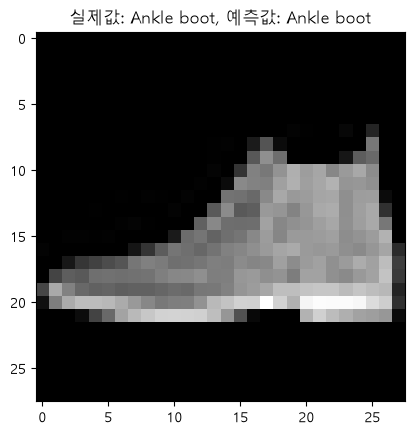

In [23]:
plt.imshow(sample_image.reshape(28, 28), cmap='gray')
plt.title(f"실제값: {class_names[sample_label]}, 예측값: {class_names[predicted_label]}")
plt.show()